# **INL2**

To find out which IDE, IDE-A or IDE-B, makes programmers more efficient, there is an experiment where 10 developers worked on Prog-1 and Prog-2 using IDE-A and IDE-B, as shown in Tables 1 and 2. I will now import this data in order to preform descriptive statistics and visualize it.

In [ ]:
import pandas as pd
pd.set_option('display.width', 200)

import matplotlib.pyplot as plt
from scipy import stats

In [ ]:

#Experiment design, assigning treatments, objects and subjects
assignment_table = pd.DataFrame({
    "Programmer": list(range(1, 11)),
    "IDE-A": ["Prog-1", "Prog-2", "Prog-1", "Prog-1", "Prog-2", "Prog-2", "Prog-1", "Prog-2", "Prog-1", "Prog-2"],
    "IDE-B": ["Prog-2", "Prog-1", "Prog-2", "Prog-2", "Prog-1", "Prog-1", "Prog-2", "Prog-1", "Prog-2", "Prog-1"],
})

#Data from the experiment
data_table = pd.DataFrame({
    "Programmer": list(range(1, 11)),
    "Prog-1_time": [104, 102, 159, 168, 150, 151, 111, 105, 137, 124],
    "Prog-2_time": [71.3, 110, 178, 153, 120, 174, 94.9, 86.1, 115, 175],
})

# We are putting the data that we have into a dataframe
df_assignment_table = pd.DataFrame(assignment_table)
df_data_table = pd.DataFrame(data_table)

# Now we are merging the dataframes into one that we will be using
df = pd.merge(df_assignment_table, df_data_table, on='Programmer')


print(df)


   Programmer   IDE-A   IDE-B  Prog-1_time  Prog-2_time
0           1  Prog-1  Prog-2          104         71.3
1           2  Prog-2  Prog-1          102        110.0
2           3  Prog-1  Prog-2          159        178.0
3           4  Prog-1  Prog-2          168        153.0
4           5  Prog-2  Prog-1          150        120.0
5           6  Prog-2  Prog-1          151        174.0
6           7  Prog-1  Prog-2          111         94.9
7           8  Prog-2  Prog-1          105         86.1
8           9  Prog-1  Prog-2          137        115.0
9          10  Prog-2  Prog-1          124        175.0


In [ ]:
# Now we determine how much time each programmer spent using IDE-A and IDE-B,
# based on which program (Prog-1 or Prog-2) they used with each IDE
df['IDE-A_time'] = df.apply(lambda row: row[row['IDE-A'] + '_time'], axis=1)
df['IDE-B_time'] = df.apply(lambda row: row[row['IDE-B'] + '_time'], axis=1)

print(df)

   Programmer   IDE-A   IDE-B  Prog-1_time  Prog-2_time  IDE-A_time  IDE-B_time
0           1  Prog-1  Prog-2          104         71.3       104.0        71.3
1           2  Prog-2  Prog-1          102        110.0       110.0       102.0
2           3  Prog-1  Prog-2          159        178.0       159.0       178.0
3           4  Prog-1  Prog-2          168        153.0       168.0       153.0
4           5  Prog-2  Prog-1          150        120.0       120.0       150.0
5           6  Prog-2  Prog-1          151        174.0       174.0       151.0
6           7  Prog-1  Prog-2          111         94.9       111.0        94.9
7           8  Prog-2  Prog-1          105         86.1        86.1       105.0
8           9  Prog-1  Prog-2          137        115.0       137.0       115.0
9          10  Prog-2  Prog-1          124        175.0       175.0       124.0


In [ ]:
# Mean (average) development time for each IDE
mean_a = df['IDE-A_time'].mean()
mean_b = df['IDE-B_time'].mean()
print("Mean IDE-A time:", mean_a, "minutes")
print("Mean IDE-B time:", mean_b, "minutes")


Mean IDE-A time: 134.41 minutes
Mean IDE-B time: 124.42 minutes


In [ ]:
# Median development time for each IDE
median_a = df['IDE-A_time'].median()
median_b = df['IDE-B_time'].median()
print("Median IDE-A time:", median_a)
print("Median IDE-B time:", median_b)

Median IDE-A time: 128.5
Median IDE-B time: 119.5


In [ ]:
# Minimum and maximum development time for each IDE
min_IDEA = df['IDE-A_time'].min()
max_IDEA = df['IDE-A_time'].max()
min_IDEB = df['IDE-B_time'].min()
max_IDEB = df['IDE-B_time'].max()

print(f"IDE-A: Min: {min_IDEA:.2f}, Max: {max_IDEA:.2f}")
print(f"IDE-B: Min: {min_IDEB:.2f}, Max: {max_IDEB:.2f}")

IDE-A: Min: 86.10, Max: 175.00
IDE-B: Min: 71.30, Max: 178.00


In [ ]:
# Standard deviation for each IDE (spread/variability of development time)
std_a = df['IDE-A_time'].std()
std_b = df['IDE-B_time'].std()
print("Std IDE-A time:", std_a)
print("Std IDE-B time:", std_b)

Std IDE-A time: 32.599810837896996
Std IDE-B time: 32.847012378939766


# **Visualization** (box plot, histograms and scatter plot)

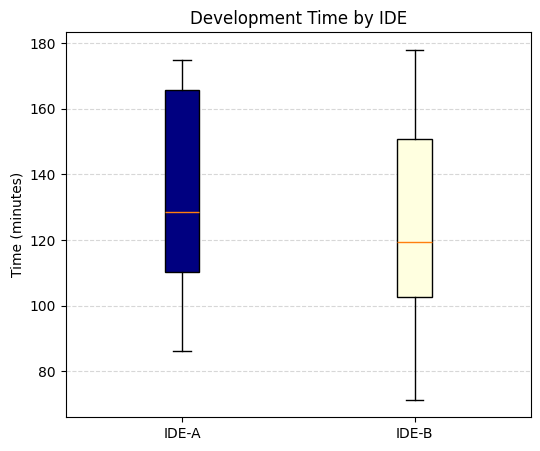

In [ ]:
# Box plot comparing development time between IDE-A and IDE-B
plt.figure(figsize=(6, 5))
box = plt.boxplot([df['IDE-A_time'], df['IDE-B_time']], tick_labels=['IDE-A', 'IDE-B'], patch_artist=True)

colors = ['navy', 'lightyellow']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Development Time by IDE')
plt.ylabel('Time (minutes)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

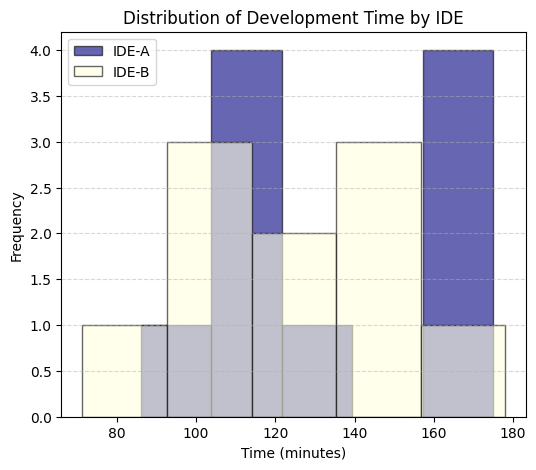

In [ ]:
# Histogram comparing the distribution of development time for IDE-A and IDE-B
plt.figure(figsize=(6, 5))
plt.hist(df['IDE-A_time'], bins=5, alpha=0.6, label='IDE-A', color='navy', edgecolor='black')
plt.hist(df['IDE-B_time'], bins=5, alpha=0.6, label='IDE-B', color='lightyellow', edgecolor='black')

plt.title('Distribution of Development Time by IDE')
plt.xlabel('Time (minutes)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

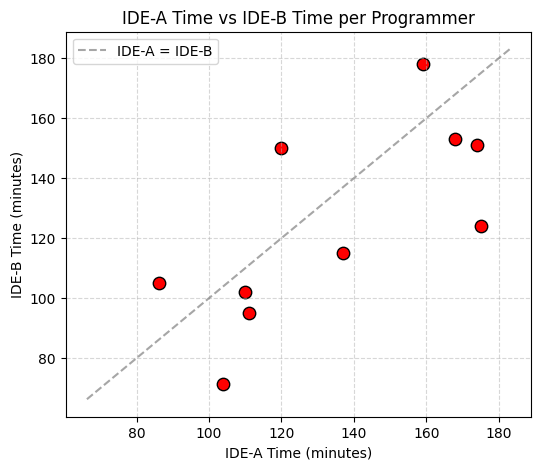

In [ ]:
# Scatter plot: each point is one programmer, comparing their IDE-A time vs IDE-B time
plt.figure(figsize=(6, 5))
plt.scatter(df['IDE-A_time'], df['IDE-B_time'], color='red', edgecolor='black', s=80)

# Add a reference line where IDE-A time equals IDE-B time
lims = [min(df['IDE-A_time'].min(), df['IDE-B_time'].min()) - 5,
        max(df['IDE-A_time'].max(), df['IDE-B_time'].max()) + 5]
plt.plot(lims, lims, linestyle='--', color='gray', alpha=0.7, label='IDE-A = IDE-B')

plt.title('IDE-A Time vs IDE-B Time per Programmer')
plt.xlabel('IDE-A Time (minutes)')
plt.ylabel('IDE-B Time (minutes)')
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.show()

In [ ]:
df['Difference'] = df['IDE-A_time'] - df['IDE-B_time']

stat, p_value = stats.shapiro(df['Difference'])
print(f"statistic = {stat:.4f}, p-value = {p_value:.4f}")

statistic = 0.9414, p-value = 0.5692


In [ ]:
# Paired t-test
t_stat, t_pvalue = stats.ttest_rel(df['IDE-A_time'], df['IDE-B_time'])
print(f"Paired t-test: t = {t_stat:.4f}, p-value = {t_pvalue:.4f}")

# Wilcoxon signed-rank test
w_stat, w_pvalue = stats.wilcoxon(df['IDE-A_time'], df['IDE-B_time'])
print(f"Wilcoxon test: w = {w_stat:.4f}, p-value = {w_pvalue:.4f}")

Paired t-test: t = 1.2389, p-value = 0.2467
Wilcoxon test: w = 17.0000, p-value = 0.3223
